# Telecom Customer Churn Prediction

## Objective

The objective of this notebook is to develop a machine learning model
that predicts whether a customer is likely to churn.

The workflow includes:

- feature selection based on EDA and business logic (avoiding multicollinearity)
- prevention of target leakage
- preprocessing of numerical and categorical variables
- train/test split
- baseline model
- multiple classification models (with class balancing for churn)
- hyperparameter tuning
- model evaluation
- threshold analysis
- feature importance (model-based and permutation-based)
- business risk segmentation
- final model selection and export
- business interpretation

The final model should balance predictive performance with
interpretability and business usefulness.

### Imports

In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve
)

### Load dataset

In [2]:
Data_Path = Path("C:/Users/Lenovo/OneDrive/Bureau/Data_portofoliu/Proiect2/telecom-churn-analysis/data/cleaned_analysis_df.csv")

df = pd.read_csv(Data_Path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (6589, 44)


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Total Revenue,Customer Status,Churn Category,Churn Reason,Churn Flag,Invalid Monthly Charge,Tenure Segment,Age Segment,Monthly Charge Segment,Usage Segment
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,974.81,Stayed,NaN,NaN,0,False,7-12 months,36-45,Medium,Low Usage
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,610.28,Stayed,NaN,NaN,0,True,7-12 months,46-55,NaN,Low Usage
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,415.45,Churned,Competitor,Competitor had better devices,1,False,0-6 months,46-55,Medium,Low Usage
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,1599.51,Churned,Dissatisfaction,Product dissatisfaction,1,False,13-24 months,65+,High,Low Usage
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,289.54,Churned,Dissatisfaction,Network reliability,1,False,0-6 months,65+,High,Low Usage


In [3]:
# Check columns
df.columns.tolist()

['Customer ID',
 'Gender',
 'Age',
 'Married',
 'Number of Dependents',
 'City',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Number of Referrals',
 'Tenure in Months',
 'Offer',
 'Phone Service',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Internet Service',
 'Internet Type',
 'Avg Monthly GB Download',
 'Online Security',
 'Online Backup',
 'Device Protection Plan',
 'Premium Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Streaming Music',
 'Unlimited Data',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charge',
 'Total Charges',
 'Total Refunds',
 'Total Extra Data Charges',
 'Total Long Distance Charges',
 'Total Revenue',
 'Customer Status',
 'Churn Category',
 'Churn Reason',
 'Churn Flag',
 'Invalid Monthly Charge',
 'Tenure Segment',
 'Age Segment',
 'Monthly Charge Segment',
 'Usage Segment']

In [4]:
# Target check
print(df["Churn Flag"].value_counts())

churn_rate = df["Churn Flag"].mean()
print(f"\nChurn rate: {churn_rate:.2%}")

Churn Flag
0    4720
1    1869
Name: count, dtype: int64

Churn rate: 28.37%


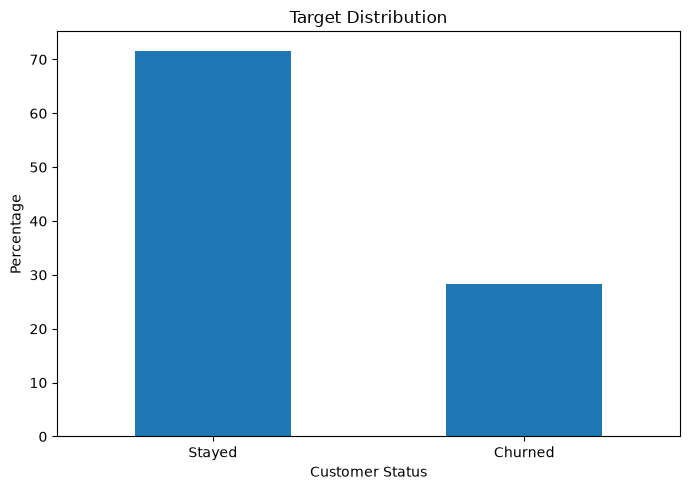

In [5]:
# Visual target distribution
churn_distribution = (
    df["Churn Flag"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

churn_distribution.index = ["Stayed", "Churned"]

churn_distribution.plot(kind="bar", figsize=(7, 5))

plt.title("Target Distribution")
plt.ylabel("Percentage")
plt.xlabel("Customer Status")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Define target and features

Target: Churn Flag

0 = Stayed

1 = Churned

In [6]:
TARGET = "Churn Flag"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Features (before leakage removal):", X.shape[1])
print("Target:", TARGET)

Features (before leakage removal): 43
Target: Churn Flag


### Prevent data leakage

Some variables must be excluded because they either describe the churn
outcome after it happened, or are practically derived from the target,
or would not be available before a customer actually churns:

- **Customer ID** — identifier with no predictive business meaning
- **Customer Status** — directly represents the outcome
- **Churn Category** — known only after the customer has churned
- **Churn Reason** — known only after the customer has churned
- **Invalid Monthly Charge** (if present) — a data-cleaning flag, not a real predictor

Using post-churn variables would artificially inflate model performance
and would make the model unsuitable for real-world churn prediction,
since none of this information exists for a customer who is still active.

In [7]:
leakage_columns = [
    "Customer ID",
    "Customer Status",
    "Churn Category",
    "Churn Reason",
    "Invalid Monthly Charge"
]

leakage_columns = [col for col in leakage_columns if col in X.columns]

X = X.drop(columns=leakage_columns)

print("Removed columns:")
print(leakage_columns)
print("\nRemaining features:", X.shape[1])

Removed columns:
['Customer ID', 'Customer Status', 'Churn Category', 'Churn Reason', 'Invalid Monthly Charge']

Remaining features: 38


### Feature selection

In [8]:
selected_features = [
    # Demographics
    "Age",
    "Number of Dependents",
    "Married",

    # Customer lifecycle
    "Tenure in Months",
    "Number of Referrals",

    # Pricing
    "Monthly Charge",

    # Usage
    "Avg Monthly GB Download",
    "Avg Monthly Long Distance Charges",

    # Service
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Internet Type",

    # Products
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data",

    # Contract / payment
    "Contract",
    "Paperless Billing",
    "Payment Method",

    # Offer
    "Offer"
]

selected_features = [col for col in selected_features if col in X.columns]

X = X[selected_features]

print("Selected features:", len(selected_features))
print(selected_features)

Selected features: 24
['Age', 'Number of Dependents', 'Married', 'Tenure in Months', 'Number of Referrals', 'Monthly Charge', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Offer']


### Feature types

In [9]:
numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:", len(numerical_features))
print(numerical_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numerical features: 7
['Age', 'Number of Dependents', 'Tenure in Months', 'Number of Referrals', 'Monthly Charge', 'Avg Monthly GB Download', 'Avg Monthly Long Distance Charges']

Categorical features: 17
['Married', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Offer']


### Train / Test split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print(f"\nTraining churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Training set: (5271, 24)
Test set: (1318, 24)

Training churn rate: 28.36%
Test churn rate: 28.38%


### Preprocessing pipeline

In [11]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

### Baseline model

In [12]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline accuracy: {baseline_accuracy:.3f}")
print(f"Baseline recall: {recall_score(y_test, baseline_pred, zero_division=0):.3f}")

Baseline accuracy: 0.716
Baseline recall: 0.000


### Evaluation function

In [13]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }

### Logistic regression

In [14]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_results = evaluate_model(logistic_model, X_test, y_test)
logistic_results

{'Accuracy': 0.8209408194233687,
 'Precision': 0.6369047619047619,
 'Recall': 0.8582887700534759,
 'F1': 0.7312072892938497,
 'ROC-AUC': 0.9122858696637361,
 'PR-AUC': 0.8058757198624626}

### Decision tree

In [15]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_results = evaluate_model(tree_model, X_test, y_test)
tree_results

{'Accuracy': 0.8361153262518968,
 'Precision': 0.691747572815534,
 'Recall': 0.7620320855614974,
 'F1': 0.7251908396946565,
 'ROC-AUC': 0.9020112956584792,
 'PR-AUC': 0.7811187224898345}

### Random Forest

In [16]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(rf_model, X_test, y_test)
rf_results

{'Accuracy': 0.8300455235204856,
 'Precision': 0.6602564102564102,
 'Recall': 0.8262032085561497,
 'F1': 0.7339667458432304,
 'ROC-AUC': 0.9224825523429712,
 'PR-AUC': 0.8437654076802036}

### Model Comparison

In [17]:
model_results = pd.DataFrame([
    {
        "Model": "Baseline",
        "Accuracy": baseline_accuracy,
        "Precision": np.nan,
        "Recall": np.nan,
        "F1": np.nan,
        "ROC-AUC": np.nan,
        "PR-AUC": np.nan
    },
    {"Model": "Logistic Regression", **logistic_results},
    {"Model": "Decision Tree", **tree_results},
    {"Model": "Random Forest", **rf_results}
])

model_results = model_results.sort_values("ROC-AUC", ascending=False)
model_results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
3,Random Forest,0.830,0.660,0.826,0.734,0.922,0.844
1,Logistic Regression,0.821,0.637,0.858,0.731,0.912,0.806
2,Decision Tree,0.836,0.692,0.762,0.725,0.902,0.781
0,Baseline,0.716,NaN,NaN,NaN,NaN,NaN


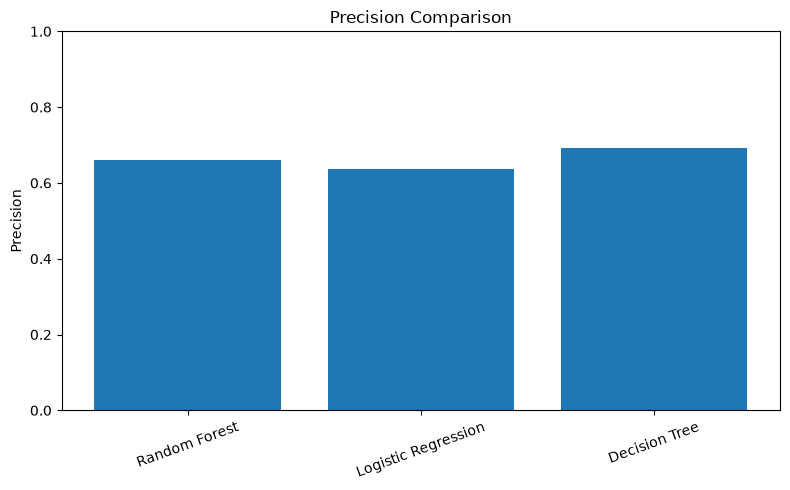

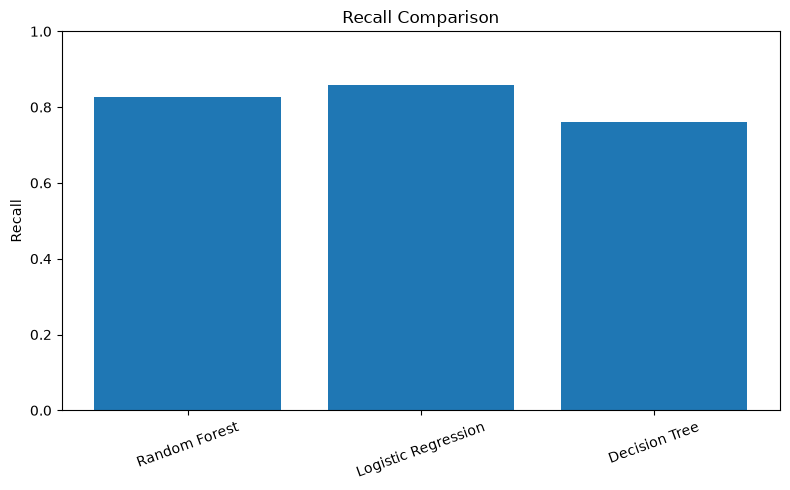

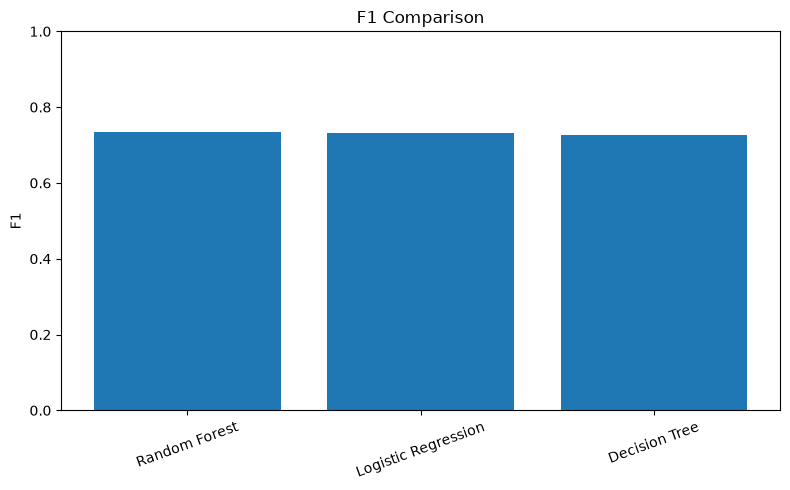

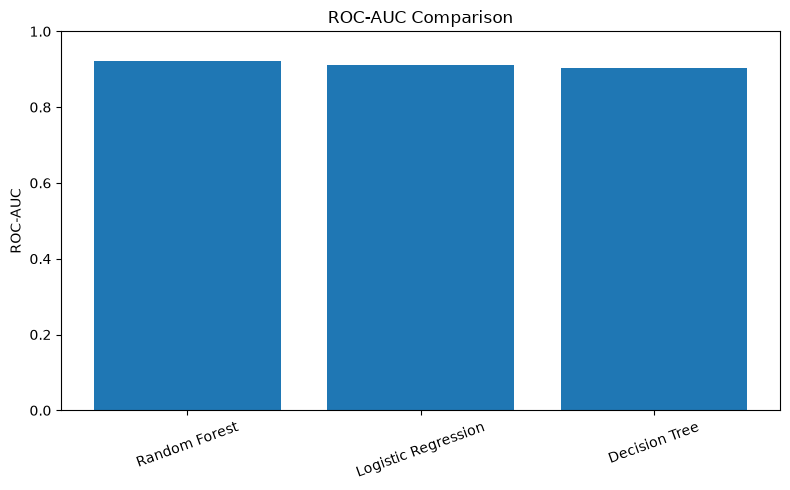

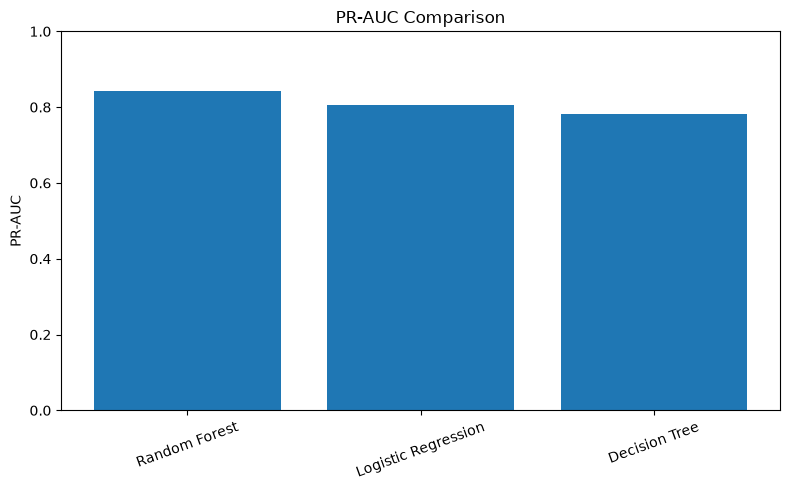

In [18]:
metrics = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    plt.bar(model_results["Model"], model_results[metric])
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

### Model selection

In [19]:
# Display model performance
model_results.sort_values(
    by=["ROC-AUC", "PR-AUC"],
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
3,Random Forest,0.830046,0.660256,0.826203,0.733967,0.922483,0.843765
1,Logistic Regression,0.820941,0.636905,0.858289,0.731207,0.912286,0.805876
2,Decision Tree,0.836115,0.691748,0.762032,0.725191,0.902011,0.781119
0,Baseline,0.716237,NaN,NaN,NaN,NaN,NaN


In [20]:
# Select the best overall model
best_model_name = (
    model_results
    .query("Model != 'Baseline'")
    .sort_values("ROC-AUC", ascending=False)
    .iloc[0]["Model"]
)

print(f"Best overall model based on ROC-AUC: {best_model_name}")

Best overall model based on ROC-AUC: Random Forest


Final model predictions

In [21]:
y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(
    X_test
)[:, 1]

Final model metrics

In [22]:
final_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_pred
    ),
    "Precision": precision_score(
        y_test,
        y_pred
    ),
    "Recall": recall_score(
        y_test,
        y_pred
    ),
    "F1": f1_score(
        y_test,
        y_pred
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_prob
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_prob
    )
}

final_metrics_df = pd.DataFrame(
    [final_metrics]
)

display(
    final_metrics_df.round(3)
)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,0.83,0.66,0.826,0.734,0.922,0.844


Classification report

In [23]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Stayed",
            "Churned"
        ]
    )
)

              precision    recall  f1-score   support

      Stayed       0.92      0.83      0.88       944
     Churned       0.66      0.83      0.73       374

    accuracy                           0.83      1318
   macro avg       0.79      0.83      0.80      1318
weighted avg       0.85      0.83      0.84      1318



### Confusion Matrix

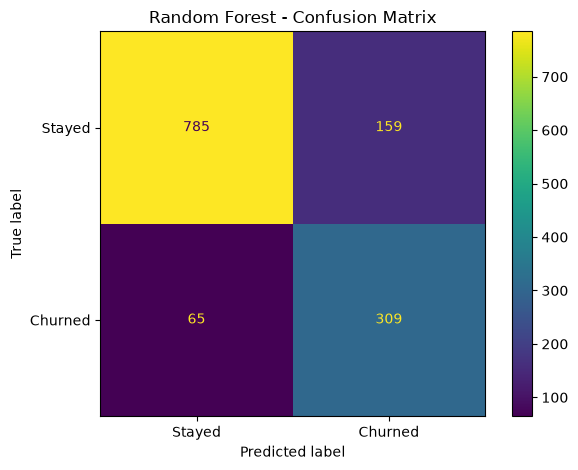

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Stayed",
        "Churned"
    ]
)

disp.plot()

plt.title(
    "Random Forest - Confusion Matrix"
)

plt.tight_layout()
plt.show()

### ROC Curve

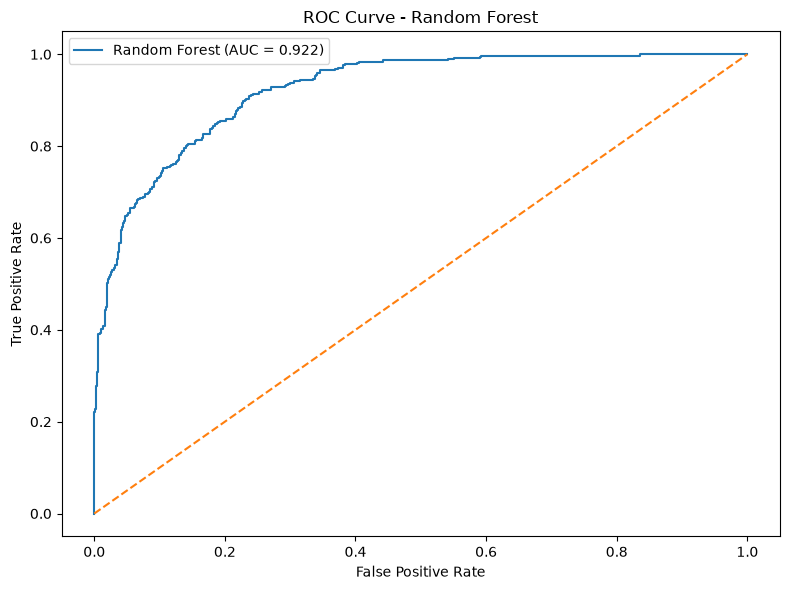

In [25]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.tight_layout()
plt.show()

ROC-AUC ≈ 0.92 indicates a very good ability of the model to distinguish between customers who churn and those who remain

### Precision-Recall Curve

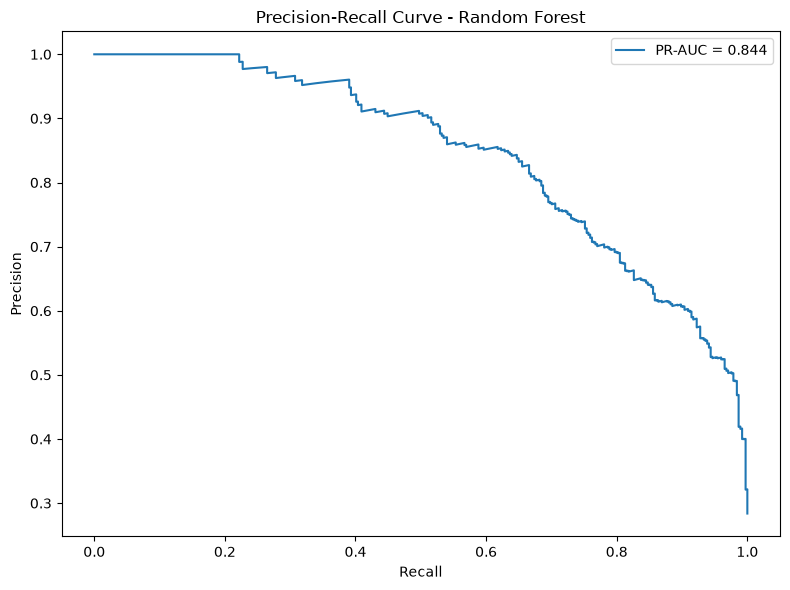

In [27]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    "Precision-Recall Curve - Random Forest"
)

plt.legend()

plt.tight_layout()
plt.show()

### Feature importance

In [28]:
fitted_preprocessor = rf_model.named_steps[
    "preprocessor"
]

rf_classifier = rf_model.named_steps[
    "classifier"
]

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    feature_importance.head(20)
)

,Feature,Importance
0,cat__Contract_Month-to-Month,0.188457
1,num__Tenure in Months,0.163466
2,cat__Contract_Two Year,0.101637
3,num__Number of Referrals,0.100832
4,num__Number of Dependents,0.052466
5,num__Monthly Charge,0.048358
6,cat__Contract_One Year,0.034426
7,cat__Internet Service_Yes,0.025147
8,cat__Internet Service_No,0.024975
9,num__Age,0.023909


### Visualize top features

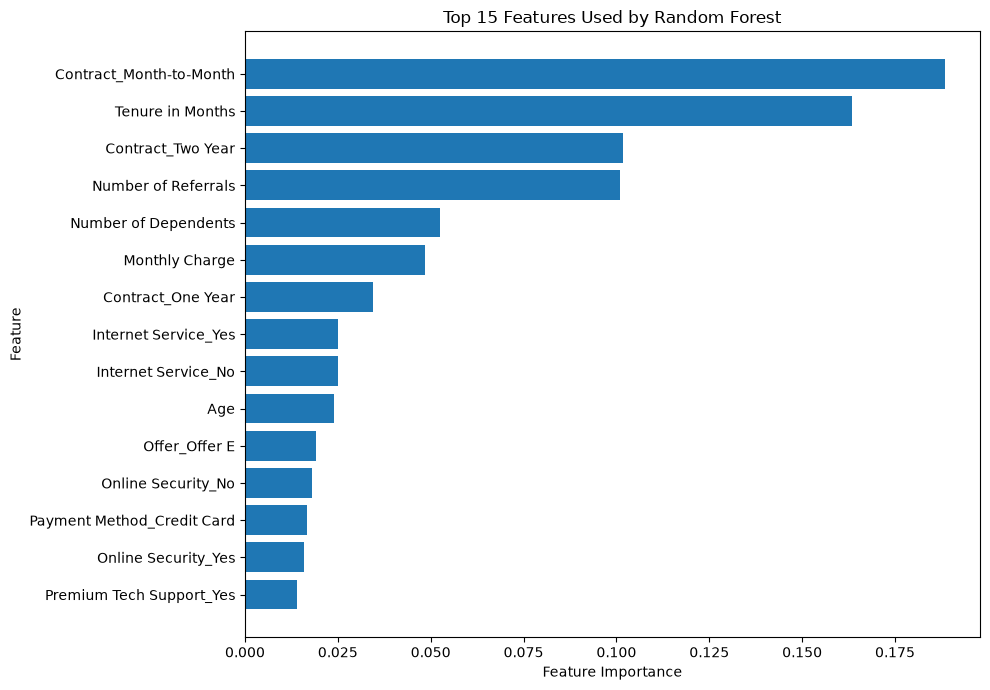

In [31]:
# Create a copy for visualization
top_features_display = feature_importance.head(15).copy()

# Remove preprocessing prefixes
top_features_display["Feature"] = (
    top_features_display["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

# Sort ascending for horizontal bar chart
top_features_display = top_features_display.sort_values(
    "Importance",
    ascending=True
)

# Plot
plt.figure(figsize=(10, 7))

plt.barh(
    top_features_display["Feature"],
    top_features_display["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Used by Random Forest")

plt.tight_layout()
plt.show()

### Key observations:

Contract_Month_to_Month is the most important category for predictions, which confirms the EDA results where contract_type have a strong correlation with churn.

In [32]:
# Create a copy
aggregated_importance = feature_importance.copy()

# Remove preprocessing prefixes
aggregated_importance["Original Feature"] = (
    aggregated_importance["Feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)

# Extract original variable names for categorical features
original_features = numerical_features + categorical_features

def identify_original_feature(feature_name):
    for original_feature in original_features:
        if feature_name == original_feature:
            return original_feature

        if feature_name.startswith(original_feature + "_"):
            return original_feature

    return feature_name


aggregated_importance["Original Feature"] = (
    aggregated_importance["Original Feature"]
    .apply(identify_original_feature)
)

# Sum importance by original feature
aggregated_importance = (
    aggregated_importance
    .groupby("Original Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(aggregated_importance.head(15))

,Original Feature,Importance
0,Contract,0.324519
1,Tenure in Months,0.163466
2,Number of Referrals,0.100832
3,Number of Dependents,0.052466
4,Internet Service,0.050123
5,Monthly Charge,0.048358
6,Online Security,0.034019
7,Premium Tech Support,0.027338
8,Offer,0.025981
9,Payment Method,0.025092


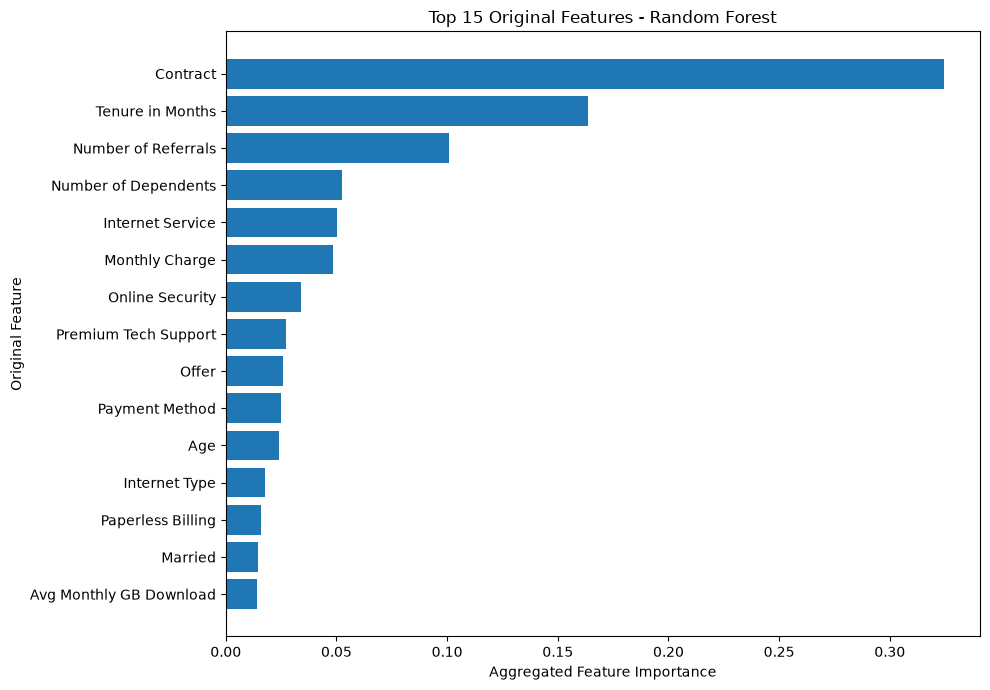

In [33]:
top_aggregated_features = (
    aggregated_importance
    .head(15)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_aggregated_features["Original Feature"],
    top_aggregated_features["Importance"]
)

plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Original Feature")
plt.title("Top 15 Original Features - Random Forest")

plt.tight_layout()
plt.show()

### Customer Churn Probabilities

In [34]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Create a predictions DataFrame
test_predictions = X_test.copy()

test_predictions["Actual Churn"] = y_test.values
test_predictions["Churn Probability"] = y_prob
test_predictions["Predicted Churn"] = y_pred

display(test_predictions.head())

,Age,Number of Dependents,Married,Tenure in Months,Number of Referrals,Monthly Charge,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Phone Service,Multiple Lines,...,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Offer,Actual Churn,Churn Probability,Predicted Churn
3922,33,2,Yes,13,4,72.80,23.0,13.77,Yes,Yes,...,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,NaN,0,0.277080,0
5312,73,0,No,1,0,69.95,27.0,22.50,Yes,No,...,No,No,No,Month-to-Month,Yes,Bank Withdrawal,Offer E,1,0.973553,1
2108,35,0,No,16,0,20.10,NaN,20.65,Yes,No,...,NaN,NaN,NaN,One Year,No,Credit Card,Offer D,0,0.045268,0
5850,55,0,Yes,33,1,91.25,17.0,26.80,Yes,No,...,Yes,Yes,No,Month-to-Month,No,Bank Withdrawal,Offer C,0,0.771735,1
1704,58,0,Yes,67,0,111.30,21.0,29.24,Yes,Yes,...,Yes,Yes,Yes,One Year,Yes,Bank Withdrawal,Offer A,1,0.517607,1


### Business risk segmentation

In [35]:
test_predictions["Risk Segment"] = pd.cut(
    test_predictions["Churn Probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

display(
    test_predictions[
        [
            "Actual Churn",
            "Churn Probability",
            "Predicted Churn",
            "Risk Segment"
        ]
    ].head(10)
)

,Actual Churn,Churn Probability,Predicted Churn,Risk Segment
3922,0,0.277080,0,Low Risk
5312,1,0.973553,1,High Risk
2108,0,0.045268,0,Low Risk
5850,0,0.771735,1,High Risk
1704,1,0.517607,1,Medium Risk
1228,0,0.099877,0,Low Risk
1320,1,0.972386,1,High Risk
4309,0,0.773196,1,High Risk
1552,1,0.502831,1,Medium Risk
4428,0,0.275664,0,Low Risk


### Risk summary

In [36]:
risk_summary = (
    test_predictions
    .groupby("Risk Segment", observed=False)
    .agg(
        Customers=("Actual Churn", "count"),
        Actual_Churn_Rate=("Actual Churn", "mean"),
        Average_Predicted_Risk=("Churn Probability", "mean")
    )
    .reset_index()
)

risk_summary["Actual_Churn_Rate"] *= 100
risk_summary["Average_Predicted_Risk"] *= 100

display(risk_summary)

,Risk Segment,Customers,Actual_Churn_Rate,Average_Predicted_Risk
0,Low Risk,656,3.201220,12.131519
1,Medium Risk,286,26.223776,44.935863
2,High Risk,376,73.936170,78.715161


### Export predictions

In [37]:
OUTPUT_DIR = Path("../data")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

predictions_path = (
    OUTPUT_DIR /
    "customer_churn_predictions.csv"
)

test_predictions.to_csv(
    predictions_path,
    index=True
)

print(
    f"Predictions saved to: {predictions_path}"
)

Predictions saved to: ..\data\customer_churn_predictions.csv


### Save model

In [38]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_path = (
    MODEL_DIR /
    "telecom_churn_random_forest.joblib"
)

joblib.dump(
    rf_model,
    model_path
)

print(
    f"Model saved to: {model_path}"
)

Model saved to: ..\models\telecom_churn_random_forest.joblib


## Final Business Conclusions

### Finding 1 — Strong predictive performance

The Random Forest model achieved strong predictive performance, with an
ROC-AUC of approximately 0.92, PR-AUC of approximately 0.84 and recall of
approximately 0.83 for the churn class.

### Finding 2 — Churn risk can be prioritized

The model generates an individual churn probability for each customer,
allowing customers to be segmented into Low, Medium and High Risk groups.

### Finding 3 — Early intervention is important

EDA showed that churned customers have substantially shorter tenure than
customers who stayed. This suggests that early customer lifecycle stages
should receive particular attention in retention strategies.

### Finding 4 — Contract and offer structure matter

Contract and Offer showed the strongest categorical associations with churn
during statistical analysis. These dimensions should therefore be monitored
when designing retention and onboarding strategies.

### Finding 5 — Pricing should be monitored

Churned customers had higher average monthly charges than customers who stayed.
This suggests a potential price-value concern that should be investigated
through targeted customer and offer analysis.

### Finding 6 — Customer engagement is relevant

Churned customers had substantially fewer referrals on average. Customer
engagement and loyalty mechanisms may therefore represent an additional area
for retention initiatives.

### Recommendation

Use the churn model as a customer prioritization tool rather than as a causal
model. High-risk customers should be evaluated together with customer value,
tenure, contract type and offer information to determine the most appropriate
retention action.

Potential actions include:
- targeted retention offers;
- contract migration incentives;
- early-tenure onboarding programs;
- pricing/value reviews;
- loyalty and referral initiatives;
- proactive customer support for high-risk segments.